TensorFlow Version: 2.21.0
17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step

Training samples: 25000
Testing samples : 25000

First review as integer sequence:
[1, 14, 22, 16, 43, 530, 973, 1622, 1385, 65, 458, 4468, 66, 3941, 4, 173, 36, 256, 5, 25]

First review label:
1

Original length of first review:
218

After padding:
Training shape: (25000, 200)
Testing shape : (25000, 200)

LSTM Model Architecture:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 32)        │       320,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 32)             │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 328,353 (1.25 MB)

 Trainable params: 328,353 (1.25 MB)

 Non-trainable params: 0 (0.00 B)


Training the LSTM...
Epoch 1/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 17s 50ms/step - accuracy: 0.7212 - loss: 0.5311 - val_accuracy: 0.8498 - val_loss: 0.3637
Epoch 2/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.8842 - loss: 0.2966 - val_accuracy: 0.8440 - val_loss: 0.3606
Epoch 3/3
313/313 ━━━━━━━━━━━━━━━━━━━━ 16s 50ms/step - accuracy: 0.9215 - loss: 0.2184 - val_accuracy: 0.8704 - val_loss: 0.3526

Test Loss     : 0.3987
Test Accuracy : 84.93 %


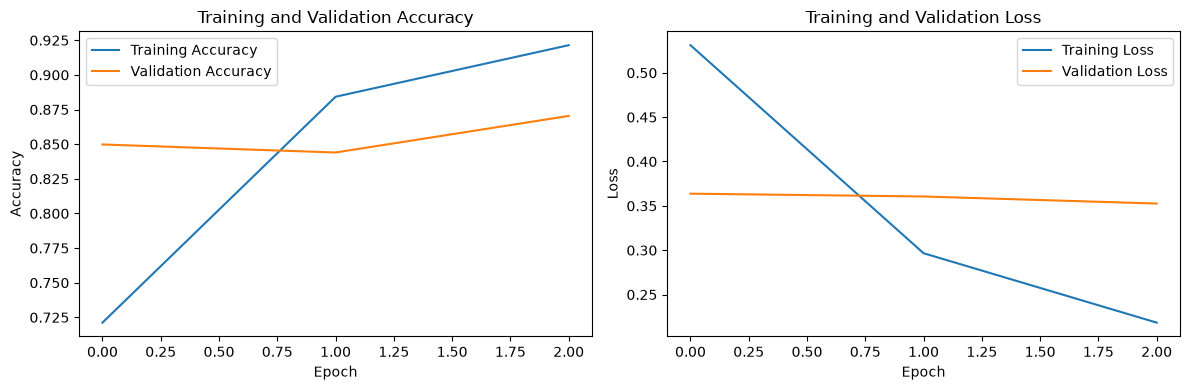


Classification Report:

              precision    recall  f1-score   support

    Negative       0.85      0.84      0.85     12500
    Positive       0.84      0.86      0.85     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



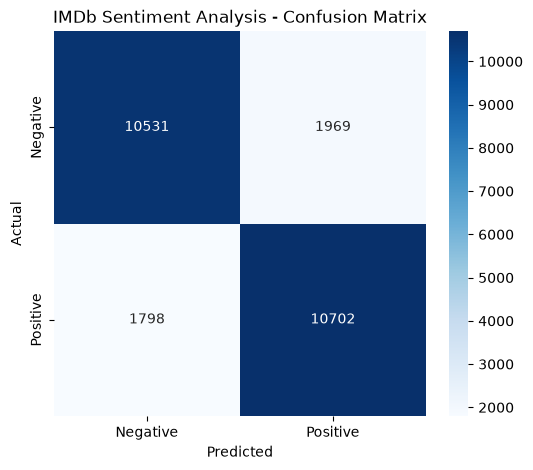


Sample Predictions:
--------------------------------
Review 1: Actual = Negative, Predicted = Negative
Review 2: Actual = Positive, Predicted = Positive
Review 3: Actual = Positive, Predicted = Positive
Review 4: Actual = Negative, Predicted = Negative
Review 5: Actual = Positive, Predicted = Positive
Review 6: Actual = Positive, Predicted = Positive
Review 7: Actual = Positive, Predicted = Positive
Review 8: Actual = Negative, Predicted = Negative
Review 9: Actual = Negative, Predicted = Positive
Review 10: Actual = Positive, Predicted = Positive

LSTM Sentiment Analysis completed!
Final Test Accuracy: 84.93 %


In [1]:
# ============================================================
# 3B. SENTIMENT ANALYSIS USING LSTM
# IMDb Movie Review Dataset
# Deep Learning & Natural Language Processing
# ============================================================

# ------------------------------------------------------------
# 1. Import Libraries
# ------------------------------------------------------------

import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras import Sequential, Input
from tensorflow.keras.layers import Embedding, LSTM, Dense

from sklearn.metrics import confusion_matrix, classification_report


print("TensorFlow Version:", tf.__version__)


# ------------------------------------------------------------
# 2. Load IMDb Dataset
# ------------------------------------------------------------

# Use the 10,000 most frequent words
VOCAB_SIZE = 10000

(x_train, y_train), (x_test, y_test) = imdb.load_data(
    num_words=VOCAB_SIZE
)

print("\nTraining samples:", len(x_train))
print("Testing samples :", len(x_test))


# ------------------------------------------------------------
# 3. Explore the Data
# ------------------------------------------------------------

print("\nFirst review as integer sequence:")
print(x_train[0][:20])

print("\nFirst review label:")
print(y_train[0])

print("\nOriginal length of first review:")
print(len(x_train[0]))


# ------------------------------------------------------------
# 4. Preprocess the Data
# ------------------------------------------------------------

# All reviews should have the same length
MAX_LENGTH = 200

x_train = pad_sequences(
    x_train,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

x_test = pad_sequences(
    x_test,
    maxlen=MAX_LENGTH,
    padding="post",
    truncating="post"
)

print("\nAfter padding:")
print("Training shape:", x_train.shape)
print("Testing shape :", x_test.shape)


# ------------------------------------------------------------
# 5. Build LSTM Model
# ------------------------------------------------------------

model = Sequential([

    # Input sequence
    Input(shape=(MAX_LENGTH,)),

    # Convert word indices into dense vectors
    Embedding(
        input_dim=VOCAB_SIZE,
        output_dim=32,
        mask_zero=True
    ),

    # LSTM layer
    LSTM(32),

    # Binary sentiment output
    Dense(1, activation="sigmoid")
])


# Display model architecture
print("\nLSTM Model Architecture:")
model.summary()


# ------------------------------------------------------------
# 6. Compile the Model
# ------------------------------------------------------------

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)


# ------------------------------------------------------------
# 7. Train the Model
# ------------------------------------------------------------

print("\nTraining the LSTM...")

history = model.fit(
    x_train,
    y_train,
    epochs=3,
    batch_size=64,
    validation_split=0.2,
    verbose=1
)


# ------------------------------------------------------------
# 8. Evaluate the Model
# ------------------------------------------------------------

test_loss, test_accuracy = model.evaluate(
    x_test,
    y_test,
    verbose=0
)

print("\nTest Loss     :", round(test_loss, 4))
print("Test Accuracy :", round(test_accuracy * 100, 2), "%")


# ------------------------------------------------------------
# 9. Plot Training History
# ------------------------------------------------------------

plt.figure(figsize=(12, 4))

# Accuracy
plt.subplot(1, 2, 1)

plt.plot(
    history.history["accuracy"],
    label="Training Accuracy"
)

plt.plot(
    history.history["val_accuracy"],
    label="Validation Accuracy"
)

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")
plt.legend()


# Loss
plt.subplot(1, 2, 2)

plt.plot(
    history.history["loss"],
    label="Training Loss"
)

plt.plot(
    history.history["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.tight_layout()
plt.show()


# ------------------------------------------------------------
# 10. Make Predictions
# ------------------------------------------------------------

# Model outputs probabilities between 0 and 1
y_pred_probability = model.predict(
    x_test,
    verbose=0
)

# Convert probabilities into 0 or 1
y_pred = (
    y_pred_probability >= 0.5
).astype(int).ravel()


# ------------------------------------------------------------
# 11. Classification Report
# ------------------------------------------------------------

print("\nClassification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Negative",
            "Positive"
        ]
    )
)


# ------------------------------------------------------------
# 12. Confusion Matrix
# ------------------------------------------------------------

cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Negative", "Positive"],
    yticklabels=["Negative", "Positive"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("IMDb Sentiment Analysis - Confusion Matrix")

plt.show()


# ------------------------------------------------------------
# 13. Display Sample Predictions
# ------------------------------------------------------------

print("\nSample Predictions:")
print("--------------------------------")

for i in range(10):

    actual = "Positive" if y_test[i] == 1 else "Negative"
    predicted = "Positive" if y_pred[i] == 1 else "Negative"

    print(
        f"Review {i + 1}: "
        f"Actual = {actual}, "
        f"Predicted = {predicted}"
    )


# ------------------------------------------------------------
# END
# ------------------------------------------------------------

print("\n======================================")
print("LSTM Sentiment Analysis completed!")
print("Final Test Accuracy:",
      round(test_accuracy * 100, 2), "%")
print("======================================")